# QASM to Circuit and DAG Examples (Qiskit)

This notebook shows three related workflows:

1. Load `.qasm` files into `QuantumCircuit` objects.
2. Convert circuits into DAGs and inspect DAG layers.
3. Use `load_qasm_to_two_qubit_dag_with_single_qubit_context` to extract:
   - a DAG containing only 2-qubit gates
   - single-qubit context grouped around 2-qubit layer boundaries.


## 1) Setup

This cell finds the repository root, adds `src/` to `sys.path`, and defines `qasm_dir`.


In [1]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "inputs" / "qasm_files").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing inputs/qasm_files and src.")


repo_root = find_repo_root(Path.cwd().resolve())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

qasm_dir = repo_root / "inputs" / "qasm_files"
print("repo_root:", repo_root)
print("qasm_dir:", qasm_dir)


repo_root: /home/gage/Quantum_Class/Phys765
qasm_dir: /home/gage/Quantum_Class/Phys765/inputs/qasm_files


## 2) Imports

We use Qiskit for circuit/DAG conversion and drawing, plus your project helper from `naive_n_dag.dag_helper`.


In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.visualization import dag_drawer

from naive_n_dag.dag_helper import (
    format_node_line,
    load_qasm_to_two_qubit_dag_with_single_qubit_context,
)


## 3) List Available QASM Files

Pick a small file first for easy visualization.


In [3]:
qasm_files = sorted(qasm_dir.glob("*.qasm"))
print(f"Found {len(qasm_files)} QASM files")
for path in qasm_files:
    print(" -", path.name)


Found 8 QASM files
 - bb144_bivariate_bicycle_cz.qasm
 - qft_5.qasm
 - qft_6.qasm
 - qft_7.qasm
 - qft_8.qasm
 - qft_n18_transpiled.qasm
 - qft_n29_transpiled.qasm
 - qft_n63_transpiled.qasm


## 4) Load QASM File into a QuantumCircuit

`QuantumCircuit.from_qasm_file(...)` is the direct Qiskit entry point.


In [4]:
example_qasm = qasm_dir / "qft_6.qasm"
qc = QuantumCircuit.from_qasm_file(str(example_qasm))

print("Loaded:", example_qasm.name)
print("num_qubits:", qc.num_qubits)
print("num_clbits:", qc.num_clbits)
print("depth:", qc.depth())
print("size:", qc.size())


Loaded: qft_6.qasm
num_qubits: 6
num_clbits: 0
depth: 12
size: 24


## 5) Draw the Circuit

- `text` draw always works in terminal/Jupyter.
- `mpl` draw is optional and needs matplotlib.


In [5]:
qc.draw("text")


»
q_0: ──────────────────────────────────────────────────────────────────────»
                                                                           »
q_1: ───────────────────────────────────────────────■──────────────────────»
                                                    │                      »
q_2: ─────────────────────────────■─────────────────┼─────────■────────────»
                                  │                 │         │       ┌───┐»
q_3: ───────────────■─────────────┼────────■────────┼─────────┼───────┤ H ├»
                    │       ┌───┐ │        │P(π/2)  │         │P(π/4) └───┘»
q_4: ──────■────────┼───────┤ H ├─┼────────■────────┼─────────■────────────»
     ┌───┐ │P(π/2)  │P(π/4) └───┘ │P(π/8)           │P(π/16)               »
q_5: ┤ H ├─■────────■─────────────■─────────────────■──────────────────────»
     └───┘                                                                 »
«                                                                           »
«q_0: ─■───────────────────────────■───────────────────────■────────────────»
«      │                           │                       │                »
«q_1: ─┼─────────■─────────────────┼─────────■─────────────┼────────■───────»
«      │         │                 │         │       ┌───┐ │        │P(π/2) »
«q_2: ─┼─────────┼────────■────────┼─────────┼───────┤ H ├─┼────────■───────»
«      │         │        │P(π/2)  │         │P(π/4) └───┘ │P(π/8)          »
«q_3: ─┼─────────┼────────■────────┼─────────■─────────────■────────────────»
«      │         │P(π/8)           │P(π/16)                                 »
«q_4: ─┼─────────■─────────────────■────────────────────────────────────────»
«      │P(π/32)                                                             »
«q_5: ─■────────────────────────────────────────────────────────────────────»
«                                                                           »
«                            ┌───┐   
«q_0: ─■─────────────■───────┤ H ├─X─
«      │       ┌───┐ │P(π/2) └───┘ │ 
«q_1: ─┼───────┤ H ├─■─────────X───┼─
«      │P(π/4) └───┘           │   │ 
«q_2: ─■─────────X─────────────┼───┼─
«                │             │   │ 
«q_3: ───────────X─────────────┼───┼─
«                              │   │ 
«q_4: ─────────────────────────X───┼─
«                                  │ 
«q_5: ─────────────────────────────X─
«

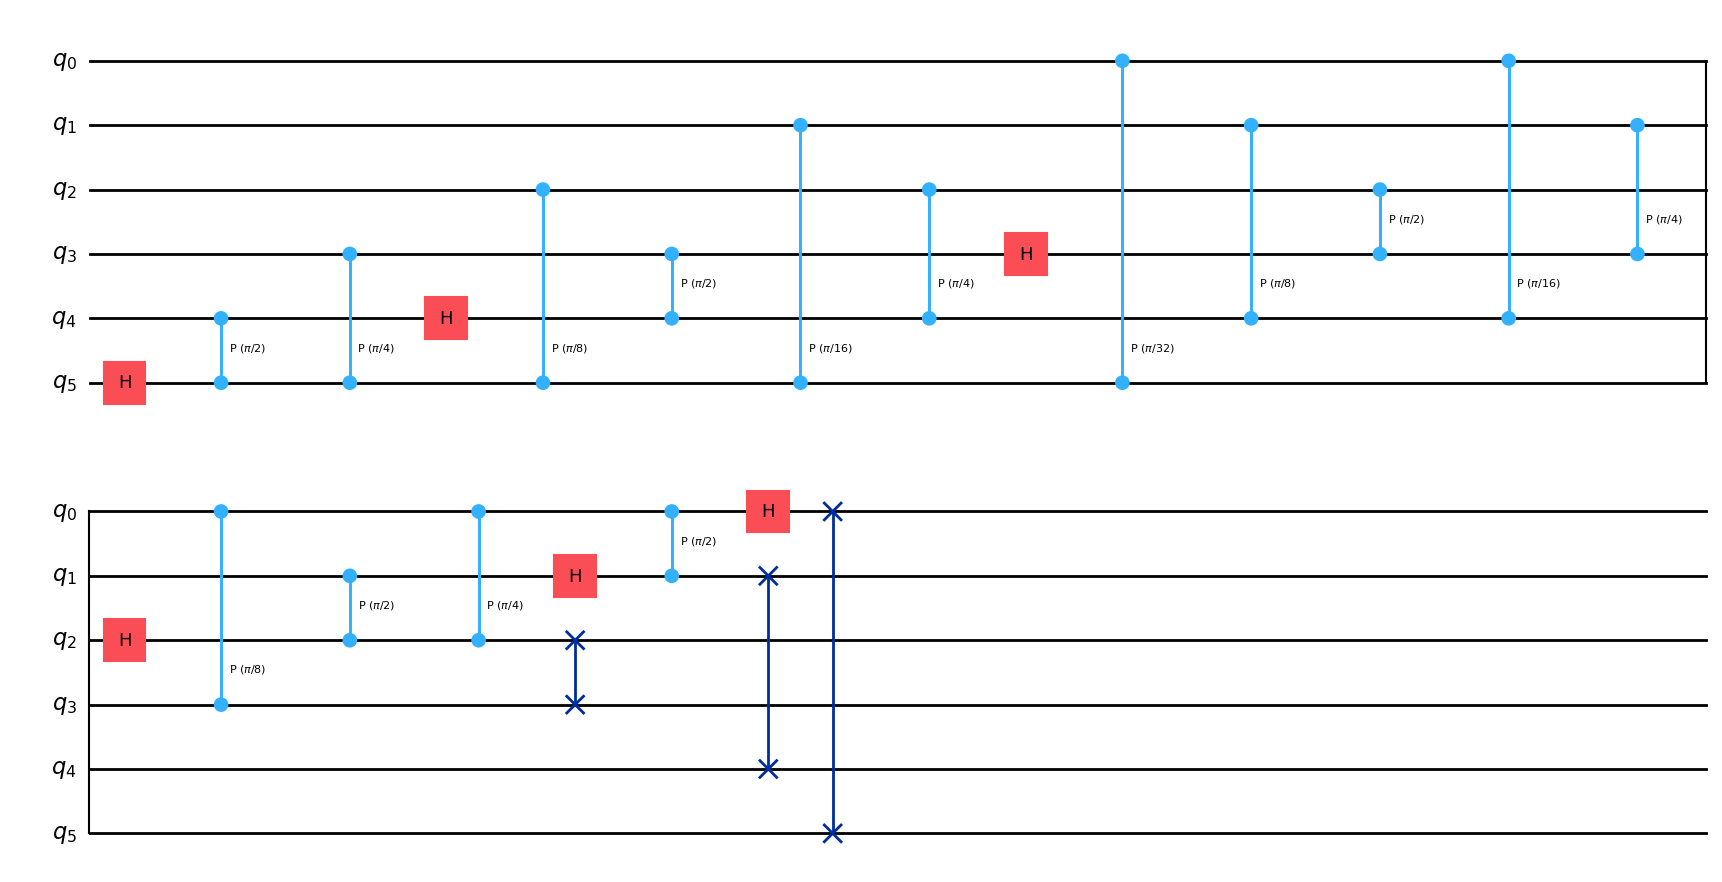

In [8]:
qc.draw("mpl")

## 6) Convert Circuit to DAG

Use `circuit_to_dag(qc)`, then inspect high-level DAG properties.


In [9]:
dag = circuit_to_dag(qc)

print("DAG summary")
print("num_qubits:", dag.num_qubits())
print("num_clbits:", dag.num_clbits())
print("depth:", dag.depth())
print("size (#op nodes):", dag.size())


DAG summary
num_qubits: 6
num_clbits: 0
depth: 12
size (#op nodes): 24


## 7) Draw the DAG

`dag_drawer` uses graphviz. If graphviz is missing, the `except` branch still gives useful data.


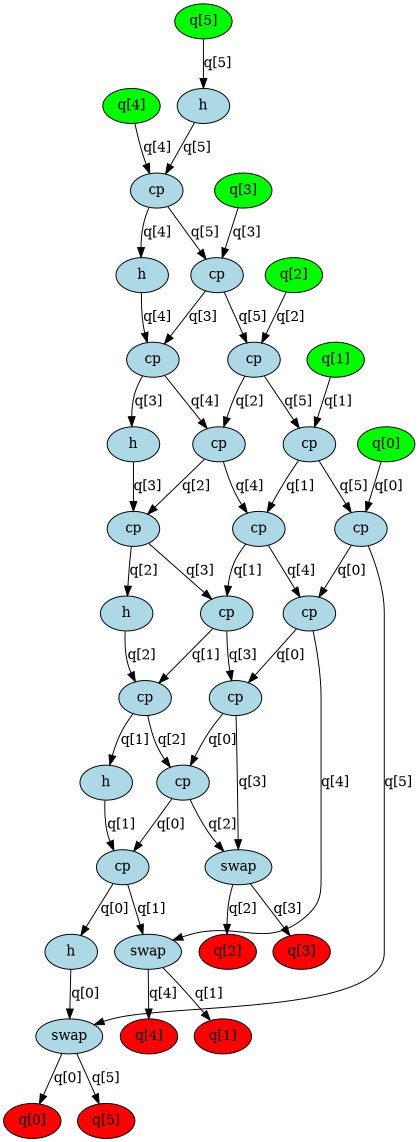

In [11]:
dag_drawer(dag)


## 8) Inspect Topological Gate Order

`dag.topological_op_nodes()` gives operations in dependency-respecting order.


In [12]:
op_nodes = list(dag.topological_op_nodes())
print("Total op nodes:", len(op_nodes))

for idx, node in enumerate(op_nodes[:12]):
    qids = [q._index for q in node.qargs]
    print(f"{idx:02d}: {node.op.name:>8} qargs={qids} params={list(node.op.params)}")


Total op nodes: 24
00:        h qargs=[5] params=[]
01:       cp qargs=[5, 4] params=[1.5707963267948966]
02:        h qargs=[4] params=[]
03:       cp qargs=[5, 3] params=[0.7853981633974483]
04:       cp qargs=[4, 3] params=[1.5707963267948966]
05:        h qargs=[3] params=[]
06:       cp qargs=[5, 2] params=[0.39269908169872414]
07:       cp qargs=[4, 2] params=[0.7853981633974483]
08:       cp qargs=[3, 2] params=[1.5707963267948966]
09:        h qargs=[2] params=[]
10:       cp qargs=[5, 1] params=[0.19634954084936207]
11:       cp qargs=[4, 1] params=[0.39269908169872414]


## 9) Inspect DAG Layers

`dag.layers()` returns depth-1 layers (parallelizable gate buckets).


In [13]:
layers = list(dag.layers())
print("Number of DAG layers:", len(layers))

for layer_idx, layer in enumerate(layers[:6]):
    ops = layer["graph"].op_nodes()
    print(f"Layer {layer_idx:02d}: {len(ops)} op(s)")
    for node in ops[:4]:
        qids = [q._index for q in node.qargs]
        print(f"   - {node.op.name} qargs={qids}")


Number of DAG layers: 12
Layer 00: 1 op(s)
   - h qargs=[5]
Layer 01: 1 op(s)
   - cp qargs=[5, 4]
Layer 02: 2 op(s)
   - cp qargs=[5, 3]
   - h qargs=[4]
Layer 03: 2 op(s)
   - cp qargs=[5, 2]
   - cp qargs=[4, 3]
Layer 04: 3 op(s)
   - cp qargs=[5, 1]
   - cp qargs=[4, 2]
   - h qargs=[3]
Layer 05: 3 op(s)
   - cp qargs=[5, 0]
   - cp qargs=[4, 1]
   - cp qargs=[3, 2]


## 10) Convert a Single Layer Back to a Circuit

Each `layer["graph"]` is itself a DAG. You can convert it back with `dag_to_circuit`.


In [14]:
layer_idx = 2
layer_dag = layers[layer_idx]["graph"]
layer_circuit = dag_to_circuit(layer_dag)

print(f"Layer {layer_idx} as circuit:")
layer_circuit.draw("text")


Layer 2 as circuit:


q_0: ──────────────
                   
q_1: ──────────────
                   
q_2: ──────────────
                   
q_3: ──────■───────
     ┌───┐ │       
q_4: ┤ H ├─┼───────
     └───┘ │P(π/4) 
q_5: ──────■───────

## 11) Use the Built-in Two-Qubit DAG Helper

`load_qasm_to_two_qubit_dag_with_single_qubit_context(path)` returns:

- `two_qubit_dag`: DAG containing only 2-qubit operations
- `single_qubit_context`: list of lists of `DAGOpNode`

Interpretation of context index `i`:
- context before two-qubit layer `i`
- final bucket `[-1]` is context after the last two-qubit layer.


In [15]:
two_qubit_dag, single_qubit_context = load_qasm_to_two_qubit_dag_with_single_qubit_context(example_qasm)

twoq_layers = list(two_qubit_dag.layers())
print("two_qubit_dag size:", two_qubit_dag.size())
print("two_qubit_dag depth:", two_qubit_dag.depth())
print("num two-qubit layers:", len(twoq_layers))
print("num context buckets:", len(single_qubit_context))
print("expected buckets == layers + 1:", len(single_qubit_context) == len(twoq_layers) + 1)


two_qubit_dag size: 15
two_qubit_dag depth: 9
num two-qubit layers: 9
num context buckets: 10
expected buckets == layers + 1: True


## 12) Show Two-Qubit Layer + Surrounding Single-Qubit Context

This is the key view used by schedulers that place 2Q interactions while preserving 1Q gate context.


In [16]:
inspect_layer = 0

print(f"Single-qubit context before two-qubit layer {inspect_layer}:")
for node in single_qubit_context[inspect_layer][:12]:
    print("  ", format_node_line(node))

print()
print(f"Two-qubit ops in layer {inspect_layer}:")
for node in twoq_layers[inspect_layer]["graph"].op_nodes()[:12]:
    print("  ", format_node_line(node))

print()
print("Single-qubit context after final two-qubit layer:")
for node in single_qubit_context[-1][:12]:
    print("  ", format_node_line(node))


Single-qubit context before two-qubit layer 0:
   h q[5];

Two-qubit ops in layer 0:
   cp(pi/2) q[5],q[4];

Single-qubit context after final two-qubit layer:
   h q[0];


## 13) Run the Same Helper on a Larger QASM File

Use a larger transpiled file to validate scalability and inspect counts.


In [17]:
large_qasm = qasm_dir / "qft_n18_transpiled.qasm"
large_twoq_dag, large_context = load_qasm_to_two_qubit_dag_with_single_qubit_context(large_qasm)
large_twoq_layers = list(large_twoq_dag.layers())

print("Loaded:", large_qasm.name)
print("two_qubit_dag size:", large_twoq_dag.size())
print("two_qubit_dag depth:", large_twoq_dag.depth())
print("num two-qubit layers:", len(large_twoq_layers))
print("num context buckets:", len(large_context))


Loaded: qft_n18_transpiled.qasm
two_qubit_dag size: 306
two_qubit_dag depth: 66
num two-qubit layers: 66
num context buckets: 67


## 14) Optional: Save Drawings to Files

Uncomment if you want static artifacts.


In [ ]:
# from qiskit.visualization import circuit_drawer
#
# out_dir = repo_root / "outputs"
# out_dir.mkdir(parents=True, exist_ok=True)
#
# circuit_drawer(qc, output="mpl", filename=str(out_dir / "example_circuit.png"))
# dag_drawer(dag, filename=str(out_dir / "example_dag.png"))
# print("Saved drawings to", out_dir)
